In [1]:
import sys
from pymatgen.io.vasp.outputs import Outcar, Vasprun
import ase
import os
import numpy as np
from ase.io import read
from ase.visualize import view
import matplotlib.pyplot as plt
import pandas as pd


sys.path.append("Users/toghrulazizli/Desktop/montemoregroup/")

from energyCorrelationFunctions import *
from coordsFunctions import *
from VibrationFunctions import *
from databaseFunctions import *

In [2]:
readAtoms_H2= read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2_gas_vib/OUTCAR')
print(readAtoms_H2)

Atoms(symbols='H2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [3]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2_gas_vib/')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([0.53413594, 0.03477929, 0.0342448 ]), array([7.25500e-06, 3.47670e-05, 6.88042e-04]))


/Users/toghrulazizli/Desktop/DFT/SettingUpCalcs/CO2_ethanol/databaseFunctions.py:17: FutureWarning: Vasp2 has been deprecated. Use the ase.calculators.vasp.Vasp class instead.
  vaspObj = Vasp2(directory=directory)


array([0.0342448 , 0.03477929, 0.53413594])

In [4]:
readAtoms_CO = read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/CO_gas_calc_vib/OUTCAR')
print(readAtoms_CO)

Atoms(symbols='CO', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [5]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/CO_gas_calc_vib/')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([0.26326274, 0.00464573, 0.00317635]), array([6.635800e-05, 3.305966e-03, 3.329339e-03]))


array([0.00317635, 0.00464573, 0.26326274])

In [6]:
readAtoms_CO2 = read('/Users/toghrulazizli/Desktop/DFT/Calculations/Gas_phase/CO2_Vib/OUTCAR')
print(readAtoms_CO2)

Atoms(symbols='CO2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [7]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/Gas_phase/CO2_Vib')
print(Vib)

eVFreq_prop=Vib[0]
eVFreqOrdered = np.sort(eVFreq_prop)
eVFreqOrdered

(array([2.94224922e-01, 1.63832331e-01, 7.86980390e-02, 7.66231040e-02,
       4.70309800e-03, 1.42230000e-04]), array([4.866000e-05, 3.084390e-04, 8.471855e-03]))


array([1.42230000e-04, 4.70309800e-03, 7.66231040e-02, 7.86980390e-02,
       1.63832331e-01, 2.94224922e-01])

In [8]:
#Ethylene reading atoms

readAtoms_H2O = read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/H2O_gas_vib/OUTCAR')
print(readAtoms_H2O)
#view(readAtoms_H2O)

Atoms(symbols='OH2', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [9]:
Vib=readVibFreq('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/C2H4_gas_vib/')
print(Vib)

eVFreq=Vib[0]
eVFreqOrdered = np.sort(eVFreq)
eVFreqOrdered

(array([0.39245514, 0.38860488, 0.38274267, 0.38128053, 0.20410906,
       0.17782362, 0.16827549, 0.14917919, 0.1293202 , 0.11722461,
       0.11571919, 0.09992917, 0.01398094, 0.01289382]), array([0.00012157, 0.00045704, 0.00052677, 0.01003423]))


array([0.01289382, 0.01398094, 0.09992917, 0.11571919, 0.11722461,
       0.1293202 , 0.14917919, 0.16827549, 0.17782362, 0.20410906,
       0.38128053, 0.38274267, 0.38860488, 0.39245514])

In [10]:
#Ethylene reading atoms

readAtoms_C2H4 = read('/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/C2H4_gas_vib/OUTCAR')
print(readAtoms_C2H4)
#view(readAtoms_H2O)

Atoms(symbols='C2H4', pbc=True, cell=[20.0, 20.1, 20.2], calculator=SinglePointDFTCalculator(...))


In [11]:
def deltaMuH2(temp, pressure):
    eVFreqOrdered= np.array([0.0342448 , 0.03477929, 0.53413594])
    
    MuH2GasPhaseEng= -6.75930865
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_H2,
                      geometry='linear',
                      symmetrynumber=2, 
                      spin=0)
    MuH2Abs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuH2Abs.append(MuH2GasPhaseEng+freeEnCorr)
        return np.array(MuH2Abs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuH2Abs.append(MuH2GasPhaseEng+freeEnCorr)
        return np.array(MuH2Abs)
    
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuH2GasPhaseEng+freeEnCorr
  

In [12]:
def deltaMuCO(temp, pressure):
    eVFreqOrdered= np.array([0.00317635, 0.00464573, 0.26326274])
    
    MuCOGasPhaseEng= -14.79618318
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_CO,
                      geometry='linear',
                      symmetrynumber=1, 
                      spin=0)
    MuCOAbs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuCOAbs.append(MuCOGasPhaseEng+freeEnCorr)
        return np.array(MuCOAbs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuCOAbs.append(MuCOGasPhaseEng+freeEnCorr)
        return np.array(MuCOAbs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuCOGasPhaseEng+freeEnCorr
            

In [13]:
def deltaMuCO2(temp, pressure):
    eVFreqOrdered= np.array([1.42230000e-04, 4.70309800e-03, 7.66231040e-02, 7.86980390e-02,
       1.63832331e-01, 2.94224922e-01])
    
    MuCO2GasPhaseEng= -22.98687490
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_CO2,
                      geometry='linear',
                      symmetrynumber=2, 
                      spin=0)
    MuCO2Abs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuCO2Abs.append(MuCO2GasPhaseEng+freeEnCorr)
        return np.array(MuCO2Abs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuCO2Abs.append(MuCO2GasPhaseEng+freeEnCorr)
        return np.array(MuCO2Abs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuCO2GasPhaseEng+freeEnCorr
            

In [14]:
def deltaMuH2O(temp, pressure):
    eVFreqOrdered= np.array([0.01075526, 0.02271387, 0.19641946, 0.46061038, 0.47463492])
    
    MuH2OGasPhaseEng= -14.22024438
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_H2O,
                      geometry='nonlinear',
                      symmetrynumber=2, 
                      spin=0)
    MuH2OAbs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuH2OAbs.append(MuH2OGasPhaseEng+freeEnCorr)
        return np.array(MuH2OAbs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuH2OAbs.append(MuH2OGasPhaseEng+freeEnCorr)
        return np.array(MuH2OAbs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuH2OGasPhaseEng+freeEnCorr
            

In [15]:
def deltaMuC2H4(temp, pressure):
    eVFreqOrdered= np.array([0.01289382, 0.01398094, 0.09992917, 0.11571919, 0.11722461,
       0.1293202 , 0.14917919, 0.16827549, 0.17782362, 0.20410906,
       0.38128053, 0.38274267, 0.38860488, 0.39245514])
    
    MuC2H4GasPhaseEng= -31.97708509
  
    
    thermo = IdealGasThermo(vib_energies=eVFreqOrdered,
                      potentialenergy=0,
                      atoms=readAtoms_C2H4,
                      geometry='nonlinear',
                      symmetrynumber=4, 
                      spin=0)
    MuC2H4Abs=[]
    if isinstance(pressure, np.ndarray):
        for i in pressure:
            freeEnCorr = thermo.get_gibbs_energy(temp, i, verbose = False)
            MuC2H4Abs.append(MuC2H4GasPhaseEng+freeEnCorr)
        return np.array(MuC2H4Abs)
            
    elif isinstance(temp, np.ndarray):
        for i in temp:
            freeEnCorr = thermo.get_gibbs_energy(i, pressure, verbose = False)
            MuC2H4Abs.append(MuC2H4GasPhaseEng+freeEnCorr)
        return np.array(MuC2H4Abs)
    else:
        freeEnCorr = thermo.get_gibbs_energy(temp, pressure, verbose = False)
        return MuC2H4GasPhaseEng+freeEnCorr
            

In [16]:
cutoff = 4/1000
def getHarmonic(realFreq, imagFreq, cutoff = cutoff, gasPhase = False, verbose = True):
    ### TODO: Add in gas-phase here too
    if gasPhase == False:
        numAtomsMove = int((len(realFreq)+len(imagFreq))/3)
        eVFreqForHarm = prepFreqForHarmonic(realFreq,numAtomsMove,cutoff = cutoff)
        harmonic = HarmonicThermo(eVFreqForHarm)
        return harmonic

#a code that takes a directory and cut off, calculates the harmonic
def calc_harmonic_from_VibCalc(dirName,cutoff,verbose = True):
    Vib_freqs=readVibFreq(dirName)
    realFreq=Vib_freqs[0]
    imagFreq=Vib_freqs[1]
    if verbose: 
        print(realFreq,imagFreq)
    
    harmonic=getHarmonic(realFreq, imagFreq, cutoff = cutoff, gasPhase = False, verbose = False)
    return harmonic

def getFreeEnergy(temp, harmonic, verbose = True):
    if isinstance(temp,np.ndarray):
        freeEnergy = []
        for i in temp:
            freeEnergy += [harmonic.get_helmholtz_energy(i,verbose = verbose)] #Includes ZPE
        return np.array(freeEnergy)
    else:
        freeEnergy = harmonic.get_helmholtz_energy(temp,verbose = verbose)
        return freeEnergy

In [17]:
P_H2 = 101325
P_CO = 101325
P_CO2 = 101325
T = 298.15   

In [27]:
mu_H2 = deltaMuH2(T, P_H2)
mu_CO = deltaMuCO(T, P_CO)
mu_CO2 = deltaMuCO2(T, P_CO2)
P_H2O = 3170 #Pa vapor pressure at 25C
mu_H2O = deltaMuH2O(T, P_H2O)
P_C2H4 = 101325*0.02
mu_C2H4 = deltaMuC2H4(T, P_C2H4)
print("Mu H2 at T =", T, "K and P =", P_H2, "Pa is:", mu_H2, "eV")
print("Mu CO at T =", T, "K and P =", P_CO, "Pa is:", mu_CO, "eV")
print("Mu CO2 at T =", T, "K and P =", P_CO2, "Pa is:", mu_CO2, "eV")
print("Mu H2O at T =", T, "K and P =", P_H2O, "Pa is:", mu_H2O, "eV")
print("Mu C2H4 at T =", T, "K and P =", P_C2H4, "Pa is:", mu_C2H4, "eV")

Mu H2 at T = 298.15 K and P = 101325 Pa is: -6.805719314942781 eV
Mu CO at T = 298.15 K and P = 101325 Pa is: -15.185624424616792 eV
Mu CO2 at T = 298.15 K and P = 101325 Pa is: -23.244517495371678 eV
Mu H2O at T = 298.15 K and P = 3170 Pa is: -14.224578688304168 eV
Mu C2H4 at T = 298.15 K and P = 2026.5 Pa is: -31.292787939939366 eV


In [28]:
import os
import pandas as pd
import ase.io

calculation_dir = '/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/'
os.chdir(calculation_dir)
parentDir = "Selectivity_Vib_Calcs_new"

data = []   # this will become the DataFrame

for dirName in sorted(os.listdir(parentDir)):
    if dirName == '.DS_Store':
        continue

    dirName_calc = dirName.replace("_vib", "")

    harmonic = calc_harmonic_from_VibCalc(
        parentDir + "/" + dirName,
        cutoff=4/1000,
        verbose=False
    )

    correction = getFreeEnergy(T, harmonic, verbose=False)

    atoms = ase.io.read(calculation_dir + dirName_calc + '/OUTCAR')
    potential_energy = atoms.get_potential_energy()

    freeEnergy = potential_energy + correction

    # store everything
    data.append({
        "Structure": dirName_calc,
        "E_DFT (eV)": potential_energy,
        "G_vib_correction (eV)": correction,
        "G_total (eV)": freeEnergy,
        "Temperature (K)": T
    })

# build DataFrame
df = pd.DataFrame(data)

# set Structure as index FIRST
df = df.set_index("Structure")

# now sort by free energy WITHOUT resetting index
df = df.sort_values("G_total (eV)")

display(df)


/Users/toghrulazizli/Desktop/DFT/SettingUpCalcs/CO2_ethanol/databaseFunctions.py:17: FutureWarning: Vasp2 has been deprecated. Use the ase.calculators.vasp.Vasp class instead.
  vaspObj = Vasp2(directory=directory)


,E_DFT (eV),G_vib_correction (eV),G_total (eV),Temperature (K)
Structure,,,,
CH3CHO_YO4PdCu_1,-459.240799,1.553712,-457.687087,298.15
C2H3O_YO4PdCu100,-454.903348,1.303070,-453.600278,298.15
O_O4YPdCu_4,-425.701033,0.195561,-425.505472,298.15
AA_Cu100,-421.603122,1.354647,-420.248476,298.15
SDI_Cu100_2,-418.077907,1.126960,-416.950947,298.15
O_Cu100,-388.865589,0.039656,-388.825934,298.15


In [29]:
E_SDI_O4YPdCu = df.loc["C2H3O_YO4PdCu100","G_total (eV)"]
E_AA_O4YPdCu = df.loc["CH3CHO_YO4PdCu_1","G_total (eV)"]
E_O_O4YPdCu = df.loc["O_O4YPdCu_4","G_total (eV)"]
E_SDI_Cu = df.loc["SDI_Cu100_2","G_total (eV)"]
E_AA_Cu = df.loc["AA_Cu100","G_total (eV)"]
E_O_Cu = df.loc["O_Cu100","G_total (eV)"]

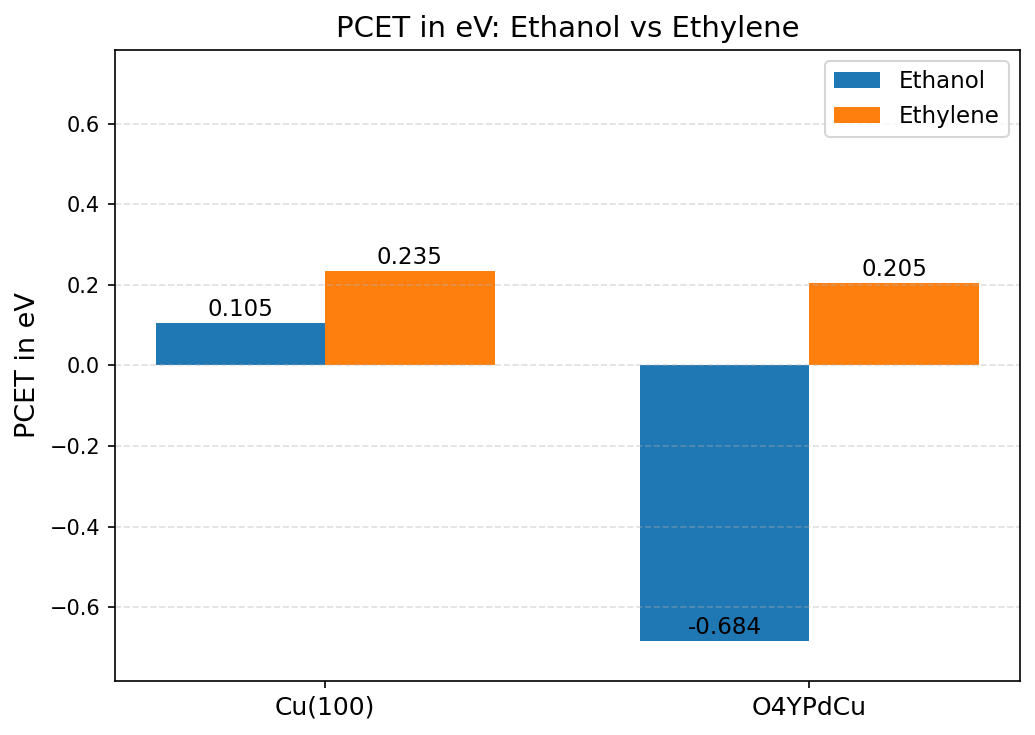

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Data (replace with your real variables) ----
# Cu(100)
Cu_ethanol  = E_AA_Cu - E_SDI_Cu - (mu_H2/2)
Cu_ethylene = E_O_Cu + mu_C2H4 - E_SDI_Cu - (mu_H2/2)

# O4YPdCu
PdCu_ethanol  = E_AA_O4YPdCu - E_SDI_O4YPdCu - (mu_H2/2)
PdCu_ethylene = E_O_O4YPdCu + mu_C2H4 - E_SDI_O4YPdCu - (mu_H2/2)

# Round
data = np.round([
    [Cu_ethanol, Cu_ethylene],
    [PdCu_ethanol, PdCu_ethylene]
], 3)

# ---- Labels ----
catalysts = ['Cu(100)', 'O4YPdCu']
products = ['Ethanol', 'Ethylene']

x = np.arange(len(catalysts))
width = 0.35

# ---- Plot ----
plt.figure(figsize=(7,5), dpi=150)

bars1 = plt.bar(x - width/2, data[:,0], width, label='Ethanol')
bars2 = plt.bar(x + width/2, data[:,1], width, label='Ethylene')

# ---- Add values on top ----
for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 val + 0.005,
                 f"{val:.3f}",
                 ha='center', va='bottom', fontsize=11)

# ---- Styling ----
plt.xticks(x, catalysts, fontsize=12)
plt.ylabel("PCET in eV", fontsize=13)
plt.title("PCET in eV: Ethanol vs Ethylene", fontsize=14)
plt.legend(fontsize=11)

max_abs = np.max(np.abs(data)) + 0.1
plt.ylim(-max_abs, max_abs)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("free_energy_pairs.png", dpi=300)
plt.show()


In [ ]:
import os
import pandas as pd
import ase.io

calculation_dir = '/Users/toghrulazizli/Desktop/DFT/Calculations/CO2_ethanol/'
os.chdir(calculation_dir)
parentDir = "Vib_Calcs_new"

data = []   # this will become the DataFrame

for dirName in sorted(os.listdir(parentDir)):
    if dirName == '.DS_Store':
        continue

    dirName_calc = dirName.replace("_vib", "")

    harmonic = calc_harmonic_from_VibCalc(
        parentDir + "/" + dirName,
        cutoff=4/1000,
        verbose=False
    )

    correction = getFreeEnergy(T, harmonic, verbose=False)

    atoms = ase.io.read(calculation_dir + dirName_calc + '/OUTCAR')
    potential_energy = atoms.get_potential_energy()

    freeEnergy = potential_energy + correction

    # store everything
    data.append({
        "Structure": dirName_calc,
        "E_DFT (eV)": potential_energy,
        "G_vib_correction (eV)": correction,
        "G_total (eV)": freeEnergy,
        "Temperature (K)": T
    })

# build DataFrame
df = pd.DataFrame(data)

# set Structure as index FIRST
df = df.set_index("Structure")

# now sort by free energy WITHOUT resetting index
df = df.sort_values("G_total (eV)")

display(df)


,E_DFT (eV),G_vib_correction (eV),G_total (eV),Temperature (K)
Structure,,,,
COCHO_4OYPdCu_5,-453.511523,0.775676,-452.735847,298.15
COCOH_4OYCu_3,-452.234058,0.841437,-451.392621,298.15
CO_CO_4OYPdCu100_4,-450.651955,0.366264,-450.285691,298.15
CO_CO_4OYPdCu100_5,-450.549729,0.433846,-450.115883,298.15
CO_CO_4OYCu100_9,-449.449087,0.416491,-449.032596,298.15
COOH_4OYPdCu100_15,-445.334283,0.707665,-444.626618,298.15
CO2_4OYPdCu100_3,-442.343327,0.347273,-441.996054,298.15
CHO_4OYPdCu100_5,-437.649756,0.579582,-437.070174,298.15
CO_4OYPdCu100_2,-434.707489,0.275827,-434.431662,298.15


## O popping up as a water

In [75]:
G_surf = df.loc["4OYPdCu100_1_4","G_total (eV)"]
G_OH = df.loc["HO_3OYPdCu_1","G_total (eV)"]
G_O2H = df.loc["H2O_3OYPdCu_1","G_total (eV)"]
G_0H_surf = df.loc["4OYPdCu100_0O_1","G_total (eV)"]

In [76]:
print(mu_H2O)

-14.224578688304168


In [77]:

# Surface states and energies
State = ["YO$_4$", "YO$_3$-OH", "YO$_3$-OH$_2$", "YO$_3$+H$_2$O"]
Energies = [0, G_OH - G_surf - (mu_H2/2), G_O2H - G_surf - mu_H2, G_0H_surf - G_surf + mu_H2O- mu_H2]



In [78]:
print(Energies)

[0, 0.39017845316166166, -0.7153670219646067, -0.22684355244371268]


In [79]:
Energies_0_49V = [0, G_OH - G_surf - (mu_H2/2) - 0.49, G_O2H - G_surf - mu_H2 - (0.49*2), G_0H_surf - G_surf + mu_H2O - mu_H2 - (0.49*2)]

In [80]:
print(Energies_0_49V)

[0, -0.09982154683833833, -1.6953670219646066, -1.2068435524437127]


In [81]:
Energies_1_0V = [0, G_OH - G_surf - (mu_H2/2) - 1, G_O2H - G_surf - mu_H2 - (1*2), G_0H_surf - G_surf + mu_H2O - mu_H2 - (1*2)]

In [82]:
print(Energies_1_0V)

[0, -0.6098215468383383, -2.7153670219646067, -2.2268435524437127]
